# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [ ]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [3]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [ ]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

print(data_standard.mean())

print(data_standard.std())

# Resultado esperado:
#media ≈ 0
#std ≈ 1


sepal length (cm)   -4.736952e-16
sepal width (cm)    -7.815970e-16
petal length (cm)   -4.263256e-16
petal width (cm)    -4.736952e-16
dtype: float64
sepal length (cm)    1.00335
sepal width (cm)     1.00335
petal length (cm)    1.00335
petal width (cm)     1.00335
dtype: float64


# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


In [13]:
stats_original = data.describe().T[['min', 'max', 'mean', 'std']]
stats_minmax = data_minmax.describe().T[['min', 'max', 'mean', 'std']]

comparacion = pd.concat(
    [stats_original, stats_minmax],
    axis=1,
    keys=['Original', 'MinMax']
)

print(comparacion)

                  Original                          MinMax                 \
                       min  max      mean       std    min  max      mean   
sepal length (cm)      4.3  7.9  5.843333  0.828066    0.0  1.0  0.428704   
sepal width (cm)       2.0  4.4  3.057333  0.435866    0.0  1.0  0.440556   
petal length (cm)      1.0  6.9  3.758000  1.765298    0.0  1.0  0.467458   
petal width (cm)       0.1  2.5  1.199333  0.762238    0.0  1.0  0.458056   

                             
                        std  
sepal length (cm)  0.230018  
sepal width (cm)   0.181611  
petal length (cm)  0.299203  
petal width (cm)   0.317599  


### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

MinMaxScaler transforma cada variable asi   x′= x−min(x)​ / [max(x)−min(x)]
el rango de valores esta entre 0 y 1  es de notar que solo cambia la escala no la forma de la distribucion.

Este método es especialmente útil cuando se necesita que todas las variables tengan una escala uniforme para evitar que aquellas con valores más grandes dominen en algoritmos sensibles a las magnitudes

Lo cual se observa claramente en las graficas.


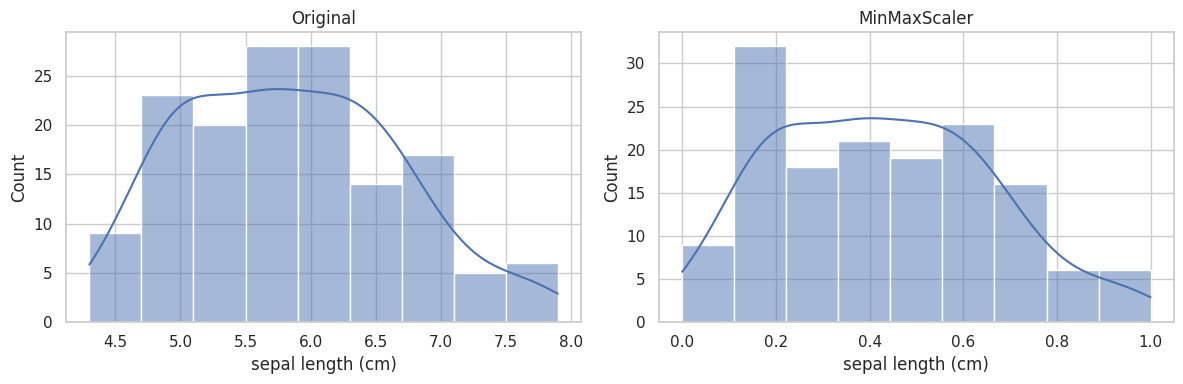

In [14]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes
sns.histplot(data['sepal length (cm)'], kde=True, ax=axes[0])
axes[0].set_title('Original')

# Después MinMax
sns.histplot(data_minmax['sepal length (cm)'], kde=True, ax=axes[1])
axes[1].set_title('MinMaxScaler')

plt.tight_layout()
plt.show()

### 3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

Como vimos StandardScaler transforma cada variable asi :  x′=  x−μ​ /σ 
es decir la relacion entre las variables no cambia solo la escala.

 Este método es ideal cuando se requiere que los datos sigan una distribución centrada y escalada

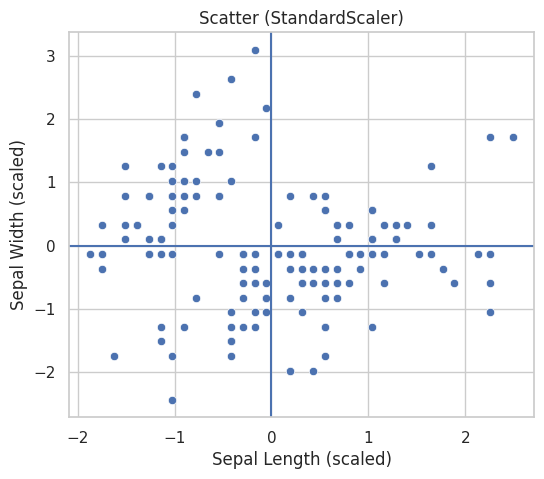

In [15]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x=data_standard['sepal length (cm)'],
    y=data_standard['sepal width (cm)']
)

plt.title('Scatter (StandardScaler)')
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.axhline(0)
plt.axvline(0)

plt.show()

### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

In [ ]:
En resumen veo que  StandardScaler 
Aqui mi analisis y justificacion:

 1. No es claro visualmente con una grafica de distribucion ya que se ven valores  compactos sin colas extendidas (pocos outliers)
 2. No es claro que los otutliers sean importantes para descartar MinMaxScaler ya que en la grafica de BoxPlot solo 'sepal width (cm)' tiene algunos 
      pro no son muchos y aunque  MinMaxScaler es sensible y es punto a favor de StandardScaler no es suficiente.
 3. No es claro uno u otro por el rango ya que ambos son [0,1]

 Dado que no es clara una eleccion u otra solo lo puedo ver desde el punto de vista de robustes y que Standarscaler centra transforma 
la distribucion centrada en 0 con desviación estándar 1 que es mejor para algoritmos basados en distancia como KNN, SVM, etc. y que MinMaxScaler 
no lo hace.

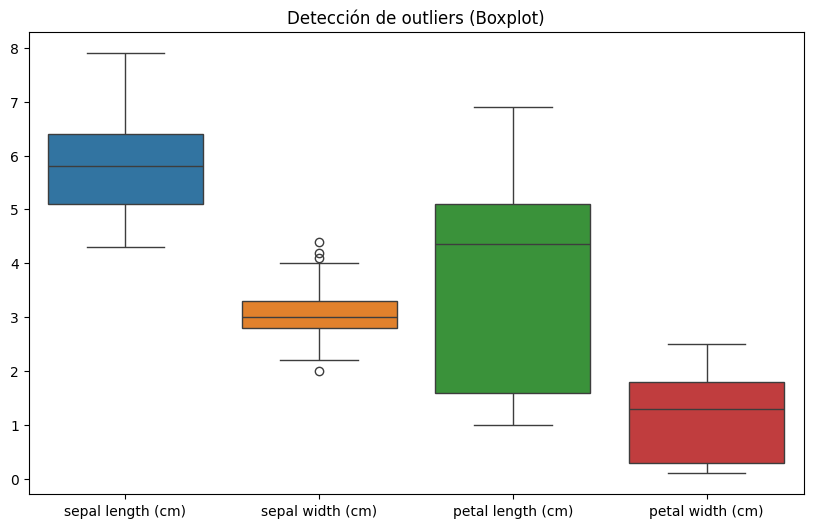

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data)
plt.title("Detección de outliers (Boxplot)")
plt.show()

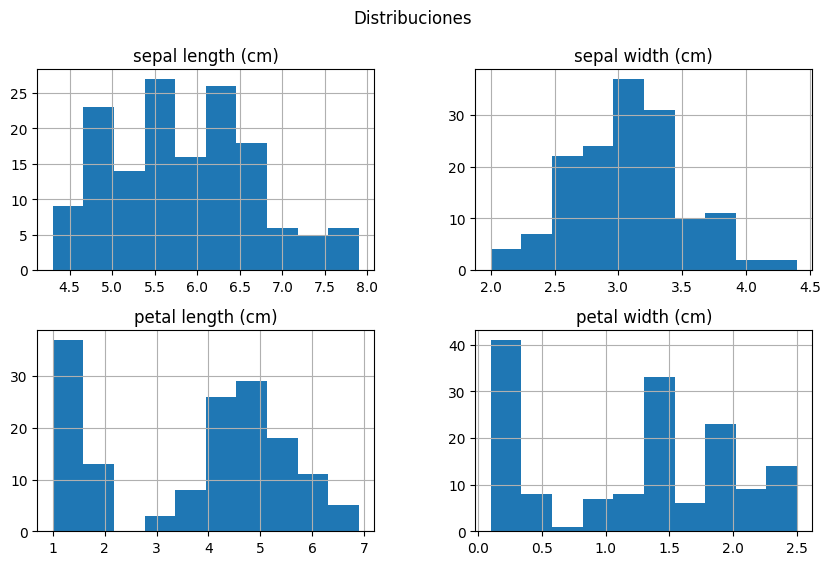

In [10]:
data.hist(figsize=(10,6))
plt.suptitle("Distribuciones")
plt.show()